In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

In [3]:
# Upload files manually in Colab before running

sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

sentiment.head(), trades.head()

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03
 3  1517722200     24   Extreme Fear  2018-02-04
 4  1517808600     11   Extreme Fear  2018-02-05,
                                       Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY 

In [4]:
print("\nSentiment Columns:\n", sentiment.columns)
print("\nTrades Columns:\n", trades.columns)

print("\nMissing Values:\n")
print(sentiment.isnull().sum())
print(trades.isnull().sum())

print("\nDuplicates:")
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())


Sentiment Columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades Columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Missing Values:

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
0
0


In [5]:
# Clean column names
sentiment.columns = sentiment.columns.str.lower()
trades.columns = trades.columns.str.lower()

# Convert dates
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms')

# Extract date only
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['timestamp'].dt.date

In [6]:
df = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

df.head()

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [7]:
# Simplify sentiment
df['sentiment'] = df['classification'].apply(
    lambda x: 'Fear' if 'Fear' in str(x) else 'Greed'
)

# Long / Short flag
df['is_long'] = df['side'].apply(lambda x: 1 if x == 'BUY' else 0)

# Daily metrics per trader
daily = df.groupby(['account', 'date']).agg({
    'closed pnl': 'sum',
    'size usd': 'mean',
    'is_long': 'mean',
    'account': 'count'
}).rename(columns={'account': 'trade_count'}).reset_index()

daily.head()

,account,date,closed pnl,size usd,is_long,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,14810.891818,0.300866,462
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,16345.241940,0.468415,3356
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,2492.749906,0.453125,320
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,1693.351684,0.432494,3533
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,1533.468395,0.403268,3427


sentiment
Fear     50.047622
Greed    46.501542
Name: closed pnl, dtype: float64


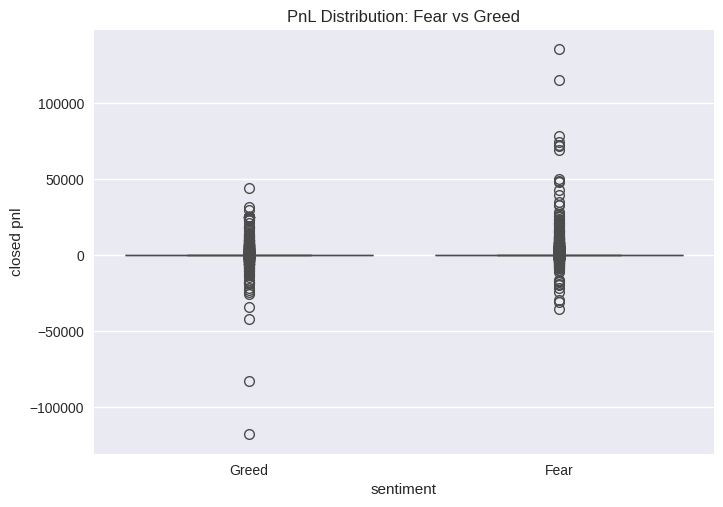

In [8]:
pnl_sentiment = df.groupby('sentiment')['closed pnl'].mean()
print(pnl_sentiment)

sns.boxplot(x='sentiment', y='closed pnl', data=df)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

              size usd   is_long
sentiment                       
Fear       5259.977837  0.493617
Greed      6296.186954  0.473349


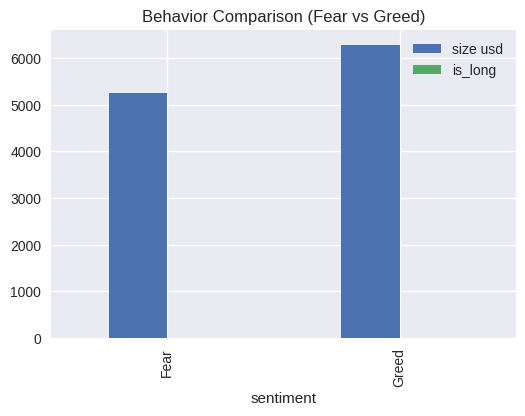

In [9]:
behavior = df.groupby('sentiment')[['size usd', 'is_long']].mean()
print(behavior)

behavior.plot(kind='bar', figsize=(6,4))
plt.title("Behavior Comparison (Fear vs Greed)")
plt.show()

sentiment
Fear     133871
Greed     77353
Name: account, dtype: int64


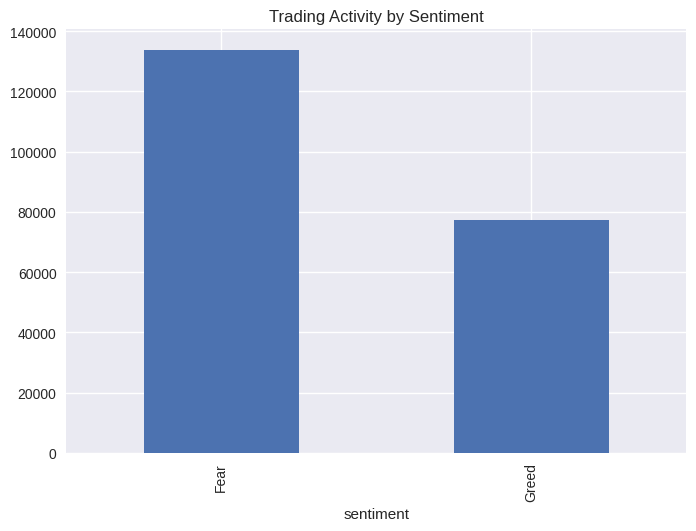

In [10]:
activity = df.groupby('sentiment')['account'].count()
print(activity)

activity.plot(kind='bar')
plt.title("Trading Activity by Sentiment")
plt.show()

trader_type
Frequent      182219.649102
Infrequent     19681.506651
Name: closed pnl, dtype: float64


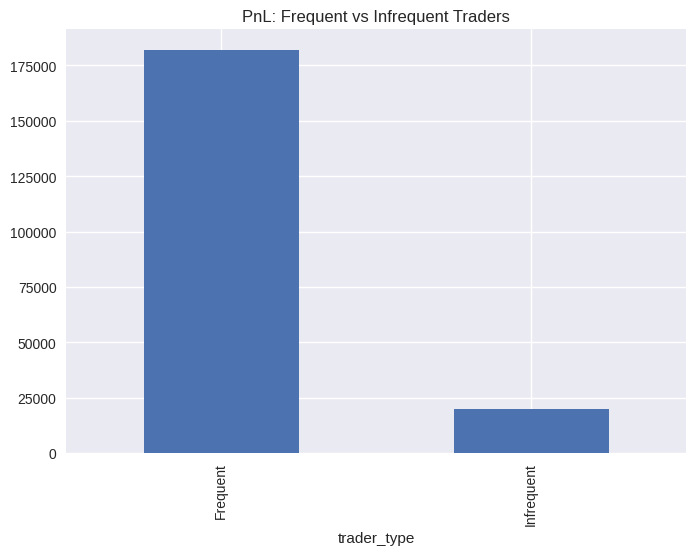

In [11]:
median_trades = daily['trade_count'].median()

daily['trader_type'] = daily['trade_count'].apply(
    lambda x: 'Frequent' if x > median_trades else 'Infrequent'
)

segmentation = daily.groupby('trader_type')['closed pnl'].mean()
print(segmentation)

segmentation.plot(kind='bar')
plt.title("PnL: Frequent vs Infrequent Traders")
plt.show()

sentiment
Fear     0.493617
Greed    0.473349
Name: is_long, dtype: float64


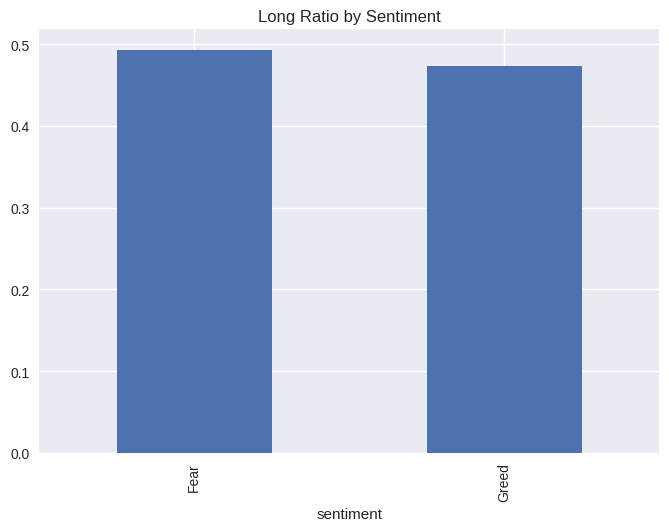

In [12]:
long_short = df.groupby('sentiment')['is_long'].mean()
print(long_short)

long_short.plot(kind='bar')
plt.title("Long Ratio by Sentiment")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Create profit label
df['profit'] = df['closed pnl'].apply(lambda x: 1 if x > 0 else 0)

features = df[['size usd', 'is_long']]
target = df['profit']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.63976801988401


In [15]:
# Aggregate to account-day
daily = df.groupby(['account', 'date']).agg(
    pnl=('closed pnl','sum'),
    avg_size=('size usd','mean'),
    long_ratio=('is_long','mean'),
    trade_count=('account','count'),
    sentiment=('sentiment','first')
).reset_index()

# Target
daily['profit'] = (daily['pnl'] > 0).astype(int)

# Encode sentiment
daily['sentiment_encoded'] = daily['sentiment'].map({'Fear': 0, 'Greed': 1})

In [16]:
daily = daily.sort_values('date')

split_idx = int(len(daily) * 0.8)
train = daily.iloc[:split_idx]
test = daily.iloc[split_idx:]

features = ['avg_size', 'long_ratio', 'trade_count', 'sentiment_encoded']

X_train, y_train = train[features], train['profit']
X_test, y_test = test[features], test['profit']

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

acc = model.score(X_test, y_test)
print("Time-aware Accuracy:", acc)

Time-aware Accuracy: 0.7142857142857143


In [18]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.79      0.88      0.83        17

    accuracy                           0.71        21
   macro avg       0.39      0.44      0.42        21
weighted avg       0.64      0.71      0.67        21



In [19]:
# Add better features
df['trade_count'] = df.groupby('account')['account'].transform('count')

df['sentiment_encoded'] = df['sentiment'].map({'Fear': 0, 'Greed': 1})

features = df[['size usd', 'is_long', 'trade_count', 'sentiment_encoded']]
target = df['profit']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Improved Accuracy:", model.score(X_test, y_test))

Improved Accuracy: 0.7842348206888389
